# Verification: MAPK relaxation oscillations (Kochanczyk et al., 2017)

This notebook verifies the curated `mapk_relaxation_oscillations_kochanczyk2017`
model at two levels.

1. **Model specification:** run the BNGL file with BioNetGen 2.9.3, compare the
   new output with the committed reference data, independently parse the
   generated 34-species/65-reaction network, integrate its mass-action ODEs
   with SciPy, compare every observable, and check conservation of all nine
   molecular pools.
2. **Reported simulation data:** compare the 20 pg/ml EGF trajectory with the
   active-ERK trace digitized from Fig. 4B in Kochanczyk et al. (2017).

The published curve was extracted from a 400-dpi rendering of page 5 of the
open-access paper PDF. The Fig. 4B left-panel axes were calibrated as
`x = 0..24 h` and `y = 0..1 ERKpp/ERKtotal`; the upper boundary of the green
filled curve was color-thresholded and resampled every 10 min. Because an
established autonomous limit cycle has arbitrary phase, peak timing is
compared after one constant phase registration and the first stimulation
transient is excluded.

**Plot convention:** solid colored lines = BioNetGen; open markers = independent
SciPy integration; thick gray line = digitized Fig. 4B.


In [1]:
import os
import re
import shutil
import subprocess
import tempfile
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
from scipy.integrate import solve_ivp
from scipy.signal import find_peaks
from scipy.sparse import csc_matrix

STEM = "mapk_relaxation_oscillations_kochanczyk2017"


def find_model_dir():
    candidates = (
        Path.cwd(),
        Path.cwd() / "models" / STEM,
        Path.cwd().parent / "models" / STEM,
    )
    for candidate in candidates:
        if (candidate / f"{STEM}.bngl").is_file():
            return candidate.resolve()
    raise FileNotFoundError("Could not locate the curated model directory")


MODEL_DIR = find_model_dir()
REF_DIR = MODEL_DIR / "reference"
PNG_FILE = MODEL_DIR / "verify_kochanczyk2017.png"
os.chdir(MODEL_DIR)
print("Model directory:", MODEL_DIR)


Model directory: /Users/l119605/Code/BNGL-Models/models/mapk_relaxation_oscillations_kochanczyk2017


In [2]:
def bionetgen_command(model_name):
    env_bng2 = os.environ.get("BNG2_PL")
    if env_bng2 and Path(env_bng2).expanduser().is_file():
        return ["perl", str(Path(env_bng2).expanduser()), model_name]
    local = Path.home() / "Simulations" / "BioNetGen-2.9.3" / "BNG2.pl"
    if local.is_file():
        return ["perl", str(local), model_name]
    cli = shutil.which("bionetgen")
    if cli:
        return [cli, "run", "-i", model_name]
    raise FileNotFoundError("BioNetGen not found; set BNG2_PL or install bionetgen")


def load_table(path):
    with open(path) as handle:
        header = handle.readline().lstrip("#").split()
    return header, np.atleast_2d(np.loadtxt(path))


def run_bionetgen():
    tmp = Path(tempfile.mkdtemp(prefix="kochanczyk2017_bng_"))
    run_model = tmp / f"{STEM}.bngl"
    run_model.write_text((MODEL_DIR / f"{STEM}.bngl").read_text())
    result = subprocess.run(
        bionetgen_command(run_model.name), cwd=tmp, capture_output=True,
        text=True, timeout=300,
    )
    assert result.returncode == 0, result.stderr or result.stdout[-3000:]
    header, gdat = load_table(tmp / f"{STEM}_ode.gdat")
    return tmp / f"{STEM}_ode.net", header, gdat


def parse_net(path):
    """Independently parse a finite BNG network for mass-action integration."""
    params, y0, patterns, reactions, groups = {}, [], [], [], []
    block = None
    for raw in open(path):
        line = raw.strip()
        if not line or line.startswith("#"):
            continue
        if line.startswith("begin "):
            block = line.split()[1]
            continue
        if line.startswith("end "):
            block = None
            continue
        body = line.split("#", 1)[0].strip()
        fields = body.split()
        if block == "parameters":
            params[fields[1]] = float(
                eval("".join(fields[2:]), {"__builtins__": {}}, params)
            )
        elif block == "species":
            patterns.append(fields[1])
            y0.append(float(eval("".join(fields[2:]), {"__builtins__": {}}, params)))
        elif block == "reactions":
            reactants = [int(x) - 1 for x in fields[1].split(",") if x != "0"]
            products = [int(x) - 1 for x in fields[2].split(",") if x != "0"]
            rate = float(eval("".join(fields[3:]), {"__builtins__": {}}, params))
            reactions.append((reactants, products, rate))
        elif block == "groups":
            group_fields = body.split(None, 2)
            members = [] if len(group_fields) < 3 else [
                (
                    int(token.split("*")[-1]) - 1,
                    float(token.split("*")[0]) if "*" in token else 1.0,
                )
                for token in group_fields[2].split(",") if token
            ]
            groups.append((group_fields[1], members))

    n_species, n_reactions = len(y0), len(reactions)
    rows, cols, values = [], [], []
    rates = np.empty(n_reactions)
    reactant_a = np.zeros(n_reactions, dtype=int)
    reactant_b = np.full(n_reactions, -1, dtype=int)
    for j, (reactants, products, rate) in enumerate(reactions):
        assert 1 <= len(reactants) <= 2, "Only uni/bimolecular reactions expected"
        rates[j] = rate
        reactant_a[j] = reactants[0]
        if len(reactants) == 2:
            reactant_b[j] = reactants[1]
        net_stoich = {}
        for i in reactants:
            net_stoich[i] = net_stoich.get(i, 0) - 1
        for i in products:
            net_stoich[i] = net_stoich.get(i, 0) + 1
        for i, value in net_stoich.items():
            if value:
                rows.append(i)
                cols.append(j)
                values.append(value)
    stoich = csc_matrix(
        (values, (rows, cols)), shape=(n_species, n_reactions)
    )
    group_matrix = np.zeros((len(groups), n_species))
    for gi, (_, members) in enumerate(groups):
        for index, weight in members:
            group_matrix[gi, index] += weight
    safe_b = reactant_b.copy()
    safe_b[reactant_b < 0] = 0
    return {
        "params": params, "y0": np.array(y0), "patterns": patterns,
        "S": stoich, "rates": rates, "ra": reactant_a,
        "rb": reactant_b, "safe_b": safe_b,
        "gnames": [group[0] for group in groups], "G": group_matrix,
        "n": n_species, "m": n_reactions,
    }


def make_rhs(net):
    bimolecular = net["rb"] >= 0

    def rhs(_time, state):
        flux = net["rates"] * state[net["ra"]]
        flux[bimolecular] *= state[net["safe_b"]][bimolecular]
        return net["S"].dot(flux)

    return rhs


## 1. Model-specification verification

Run the curated BNGL file from a clean temporary directory. The rerun must
match the committed reference output, and an independent SciPy integration
of the generated network must match every BioNetGen observable.


In [3]:
net_path, bng_header, bng = run_bionetgen()
ref_header, reference = load_table(REF_DIR / f"{STEM}_ode.gdat")
assert bng_header == ref_header
reference_error = np.max(
    np.abs(bng - reference) / np.maximum(np.abs(reference), 1.0)
)
assert reference_error <= 1e-3

net = parse_net(net_path)
assert (net["n"], net["m"]) == (34, 65)
time = bng[:, 0]
solution = solve_ivp(
    make_rhs(net), (time[0], time[-1]), net["y0"], method="LSODA",
    t_eval=time, rtol=1e-9, atol=1e-3,
)
assert solution.success, solution.message
scipy_observables = net["G"] @ solution.y

max_relative_error = 0.0
l2_errors = {}
for gi, group_name in enumerate(net["gnames"]):
    bng_values = bng[:, bng_header.index(group_name)]
    scipy_values = scipy_observables[gi]
    relative = np.abs(bng_values - scipy_values) / np.maximum(np.abs(bng_values), 1.0)
    max_relative_error = max(max_relative_error, float(relative.max()))
    l2_errors[group_name] = float(
        np.linalg.norm(bng_values - scipy_values) /
        max(np.linalg.norm(bng_values), 1.0)
    )
assert max_relative_error < 5e-4

# Each species pattern is weighted by its count of the named molecule.
pool_names = ("EGFR", "RAS", "SOS", "RasGAP", "RAF", "MEK", "ERK", "EKAR3", "ERKTR")
conservation_errors = {}
for molecule in pool_names:
    pattern = rf"(?<![A-Za-z0-9_]){re.escape(molecule)}\("
    weights = np.array([len(re.findall(pattern, item)) for item in net["patterns"]])
    total = weights @ solution.y
    conservation_errors[molecule] = float(
        np.max(np.abs(total - total[0])) / max(abs(total[0]), 1.0)
    )
assert max(conservation_errors.values()) < 1e-8

print(f"Network: {net['n']} species, {net['m']} reactions")
print(f"Fresh BNG vs committed reference max relative error: {reference_error:.2e}")
print(f"BNG vs independent SciPy max relative error: {max_relative_error:.2e}")
print(f"Largest normalized L2 error: {max(l2_errors.values()):.2e}")
print(f"Largest molecular-pool conservation error: {max(conservation_errors.values()):.2e}")


Network: 34 species, 65 reactions
Fresh BNG vs committed reference max relative error: 0.00e+00
BNG vs independent SciPy max relative error: 2.28e-04
Largest normalized L2 error: 5.04e-06
Largest molecular-pool conservation error: 9.91e-13


## 2. Reported-data verification: Fig. 4B

The digitized curve is sampled every 10 min, whereas BioNetGen is sampled
every 1 min. For this sharp relaxation oscillator we therefore compare
features robust to digitization: pulse count, median period, steady-cycle
peak amplitude, and residual peak-time error after one constant phase shift.

**Tolerances:** period error <= 6%; peak-amplitude error <= 3% of the full
vertical scale; and median phase-aligned peak-time residual <= 10 min. These
bounds reflect the 10-min digitized sampling, thick filled curve, and the
arbitrary phase of an established autonomous limit cycle.


In [4]:
digitized = np.genfromtxt(
    REF_DIR / "kochanczyk2017_fig4b_erkpp_digitized.csv",
    delimiter=",", names=True,
)
erk_total = net["params"]["ERK_tot"]
bng_erk_fraction = bng[:, bng_header.index("Obs_ERK_PP")] / erk_total
scipy_erk_fraction = (
    scipy_observables[net["gnames"].index("Obs_ERK_PP")] / erk_total
)

bng_peaks, _ = find_peaks(bng_erk_fraction, height=0.5, distance=60)
paper_peaks, _ = find_peaks(
    digitized["erk_pp_fraction"], height=0.5, distance=5,
)
assert len(bng_peaks) == len(paper_peaks) == 17

# Exclude the first stimulation transient; compare the 16 established pulses.
bng_peak_times = time[bng_peaks[1:]]
paper_peak_times = digitized["time_s"][paper_peaks[1:]]
phase_shift = float(np.median(paper_peak_times - bng_peak_times))
phase_residuals = paper_peak_times - (bng_peak_times + phase_shift)
median_timing_error = float(np.median(np.abs(phase_residuals)))
bng_period = float(np.median(np.diff(bng_peak_times)))
paper_period = float(np.median(np.diff(paper_peak_times)))
period_relative_error = abs(bng_period - paper_period) / paper_period
bng_peak_amplitude = float(np.median(bng_erk_fraction[bng_peaks[1:]]))
paper_peak_amplitude = float(
    np.median(digitized["erk_pp_fraction"][paper_peaks[1:]])
)
peak_amplitude_error = abs(bng_peak_amplitude - paper_peak_amplitude)

assert period_relative_error <= 0.06
assert peak_amplitude_error <= 0.03
assert median_timing_error <= 600

print(f"Pulse count (BNG / digitized): {len(bng_peaks)} / {len(paper_peaks)}")
print(f"Median period: BNG {bng_period/3600:.3f} h; "
      f"digitized {paper_period/3600:.3f} h; error {period_relative_error*100:.2f}%")
print(f"Median steady peak: BNG {bng_peak_amplitude:.3f}; "
      f"digitized {paper_peak_amplitude:.3f}; error {peak_amplitude_error*100:.2f}% FS")
print(f"Registered phase shift: {phase_shift/60:.1f} min; "
      f"median residual timing error {median_timing_error/60:.1f} min")


Pulse count (BNG / digitized): 17 / 17
Median period: BNG 1.433 h; digitized 1.500 h; error 4.44%
Median steady peak: BNG 0.759; digitized 0.750; error 0.90% FS
Registered phase shift: 12.5 min; median residual timing error 3.0 min


## Verification figure

The first panel shows the independently reconstructed mass-action dynamics.
The second overlays the reported Fig. 4B trace after applying the single
phase registration quantified above.


Saved /Users/l119605/Code/BNGL-Models/models/mapk_relaxation_oscillations_kochanczyk2017/verify_kochanczyk2017.png


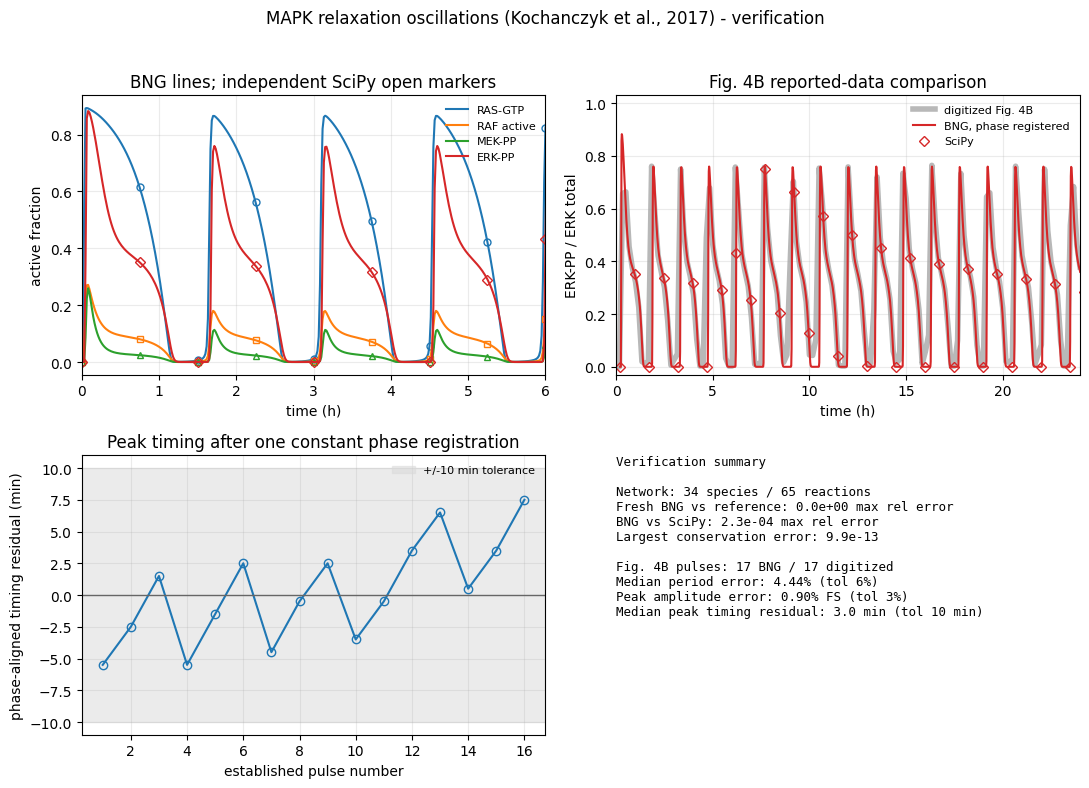

In [5]:
fig, axes = plt.subplots(2, 2, figsize=(11, 8))
colors = plt.rcParams["axes.prop_cycle"].by_key()["color"]
series = [
    ("Obs_RAS_GTP", net["params"]["RAS_tot"], "RAS-GTP", "o"),
    ("Obs_RAF_Active", net["params"]["RAF_tot"], "RAF active", "s"),
    ("Obs_MEK_PP", net["params"]["MEK_tot"], "MEK-PP", "^"),
    ("Obs_ERK_PP", net["params"]["ERK_tot"], "ERK-PP", "D"),
]
ax = axes[0, 0]
for index, (name, total, label, marker) in enumerate(series):
    color = colors[index]
    bng_values = bng[:, bng_header.index(name)] / total
    scipy_values = scipy_observables[net["gnames"].index(name)] / total
    ax.plot(time / 3600, bng_values, color=color, lw=1.5, label=label)
    ax.plot(time[::45] / 3600, scipy_values[::45], marker, mfc="none",
            mec=color, ms=5, linestyle="none")
ax.set_xlim(0, 6)
ax.set_xlabel("time (h)")
ax.set_ylabel("active fraction")
ax.set_title("BNG lines; independent SciPy open markers")
ax.grid(alpha=0.25)
ax.legend(frameon=False, fontsize=8)

ax = axes[0, 1]
ax.plot(digitized["time_s"] / 3600, digitized["erk_pp_fraction"],
        color="0.65", lw=4, alpha=0.8, label="digitized Fig. 4B")
ax.plot((time + phase_shift) / 3600, bng_erk_fraction,
        color=colors[3], lw=1.5, label="BNG, phase registered")
ax.plot((time[::45] + phase_shift) / 3600, scipy_erk_fraction[::45], "D",
        mfc="none", mec=colors[3], ms=5, linestyle="none", label="SciPy")
ax.set_xlim(0, 24)
ax.set_ylim(-0.03, 1.03)
ax.set_xlabel("time (h)")
ax.set_ylabel("ERK-PP / ERK total")
ax.set_title("Fig. 4B reported-data comparison")
ax.grid(alpha=0.25)
ax.legend(frameon=False, fontsize=8)

ax = axes[1, 0]
ax.plot(np.arange(1, len(phase_residuals) + 1), phase_residuals / 60,
        "o-", color=colors[0], mfc="none")
ax.axhline(0, color="0.4", lw=1)
ax.axhspan(-10, 10, color="0.85", alpha=0.5, label="+/-10 min tolerance")
ax.set_xlabel("established pulse number")
ax.set_ylabel("phase-aligned timing residual (min)")
ax.set_title("Peak timing after one constant phase registration")
ax.grid(alpha=0.25)
ax.legend(frameon=False, fontsize=8)

ax = axes[1, 1]
ax.axis("off")
summary = [
    "Verification summary", "",
    f"Network: {net['n']} species / {net['m']} reactions",
    f"Fresh BNG vs reference: {reference_error:.1e} max rel error",
    f"BNG vs SciPy: {max_relative_error:.1e} max rel error",
    f"Largest conservation error: {max(conservation_errors.values()):.1e}", "",
    f"Fig. 4B pulses: {len(bng_peaks)} BNG / {len(paper_peaks)} digitized",
    f"Median period error: {period_relative_error*100:.2f}% (tol 6%)",
    f"Peak amplitude error: {peak_amplitude_error*100:.2f}% FS (tol 3%)",
    f"Median peak timing residual: {median_timing_error/60:.1f} min (tol 10 min)",
]
ax.text(0, 1, "\n".join(summary), va="top", family="monospace", fontsize=9)

fig.suptitle("MAPK relaxation oscillations (Kochanczyk et al., 2017) - verification")
fig.tight_layout(rect=[0, 0, 1, 0.96])
fig.savefig(PNG_FILE, dpi=150)
print("Saved", PNG_FILE)
plt.show()
